
# Computational Track Starter Notebook

This notebook is a quick and dirty starter kit for **Quantum Circuit Placement, Routing & Scheduling**. It is designed to do three things:

1. make the compilation problem concrete,
2. give teams a clearly beatable baseline, and
3. provide just enough tooling to inspect, score, and visualize your own ideas.

It deliberately **does not** implement a strong solver. The provided routing baseline uses identity-style placement, greedy shortest-path SWAP insertion, and no placement optimization.

## Verified references

- IBM Quantum SABRE tutorial: https://quantum.cloud.ibm.com/docs/en/tutorials/transpilation-optimizations-with-sabre
- NetworkX shortest-path docs: https://networkx.org/documentation/stable/reference/algorithms/shortest_paths.html
- PennyLane circuit compilation demo: https://pennylane.ai/qml/demos/tutorial_circuit_compilation
- Matplotlib animation docs: https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.FuncAnimation.html


In [1]:

import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', tempfile.mkdtemp(prefix='mplcfg-'))

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / 'starter_kit').exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / 'Computational Track' / 'starter_kit').exists():
    sys.path.insert(0, str(NOTEBOOK_DIR / 'Computational Track'))

import matplotlib.pyplot as plt
import networkx as nx
import pennylane as qml
from IPython.display import HTML, Markdown, display

from starter_kit.baseline_routing import solve as baseline_solve
from starter_kit.benchmarks import BENCHMARKS, benchmark_stats
from starter_kit.hardware import HARDWARE_POSITIONS, build_hardware_graph
from starter_kit.scorer import schedule_layers_ordered, score_summary
from starter_kit.visualize import animate_layers, draw_hardware

plt.style.use('seaborn-v0_8-whitegrid')
GRAPH = build_hardware_graph()
print('Loaded starter kit modules.')
print('Hardware graph:', GRAPH.number_of_nodes(), 'nodes /', GRAPH.number_of_edges(), 'edges')
print('PennyLane version:', qml.__version__)


Loaded starter kit modules.
Hardware graph: 20 nodes / 23 edges
PennyLane version: 0.44.1



## 1. Hardware Graph

The public handout now describes this as a **heavy-hex-style teaching graph** rather than an exact vendor device. That keeps the challenge honest while still giving teams the right graph-theoretic structure: low degree, long shortest paths, and nontrivial routing pressure.


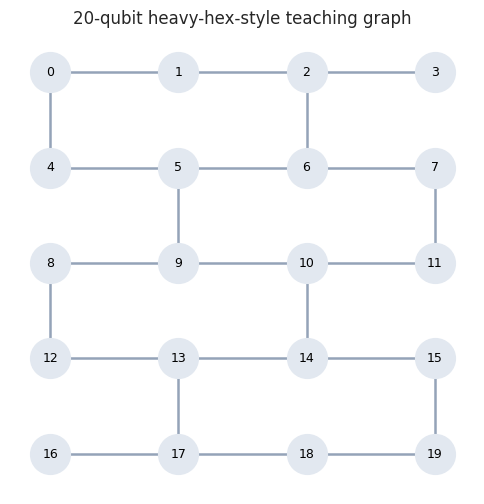

Connected: True
Diameter: 9
Max degree: 3
Shortest path 0 -> 15: [0, 4, 5, 9, 10, 14, 15]


In [2]:

fig, ax = plt.subplots(figsize=(6, 6))
draw_hardware(graph=GRAPH, ax=ax, title='20-qubit heavy-hex-style teaching graph')
plt.show()

print('Connected:', nx.is_connected(GRAPH))
print('Diameter:', nx.diameter(GRAPH))
print('Max degree:', max(dict(GRAPH.degree()).values()))
print('Shortest path 0 -> 15:', nx.shortest_path(GRAPH, 0, 15))



## 2. A Toy Routing Walkthrough

We start with a single interaction between logical qubits `L0` and `L3`. The point of this section is not to hand teams a full router; it is to make the bookkeeping visible.


In [3]:

toy_program = [('2Q', 0, 3)]
toy_start = {0: 0, 3: 11}
path = nx.shortest_path(GRAPH, toy_start[0], toy_start[3])

frames = [dict(toy_start)]
current = dict(toy_start)
for left, right in zip(path[:-2], path[1:-1]):
    next_state = dict(current)
    moved = None
    for logical, physical in current.items():
        if physical == left:
            moved = logical
            next_state[logical] = right
        elif physical == right:
            next_state[logical] = left
    current = next_state
    frames.append(dict(current))

print('Shortest path:', path)
print('Inserted SWAPs:', list(zip(path[:-2], path[1:-1])))
print('Final placement:', frames[-1])


Shortest path: [0, 1, 2, 6, 7, 11]
Inserted SWAPs: [(0, 1), (1, 2), (2, 6), (6, 7)]
Final placement: {0: 7, 3: 11}


In [4]:

from starter_kit.visualize import animate_placements

routing_anim = animate_placements(
    frames,
    highlight_edges=list(zip(path[:-2], path[1:-1])),
    title_prefix='Move L0 toward L3 | frame',
    interval=900,
)
display(HTML(routing_anim.to_jshtml()))
plt.close('all')



The animation shows the exact bookkeeping the scorer will later verify:

- every inserted `SWAP` must live on a hardware edge,
- the logical-to-physical mapping must stay consistent after each swap, and
- the original logical interaction must still occur in order.



## 3. Scheduling Is Ordered, Not Just Parallel

The organizer spec expects scheduling to respect the **original operation order**. That means a gate cannot jump ahead just because its qubits are free. The example below matches the handout's depth-3 explanation.


In [5]:

scheduling_example = [
    ('2Q', 0, 1),
    ('2Q', 4, 5),
    ('2Q', 1, 2),
    ('2Q', 5, 6),
    ('2Q', 2, 6),
]
layers = schedule_layers_ordered(scheduling_example)
for index, layer in enumerate(layers, start=1):
    print(f'Layer {index}: {layer}')
print('Depth:', len(layers))


Layer 1: [('2Q', 0, 1), ('2Q', 4, 5)]
Layer 2: [('2Q', 1, 2), ('2Q', 5, 6)]
Layer 3: [('2Q', 2, 6)]
Depth: 3


In [6]:

layer_anim = animate_layers(layers, interval=1000)
display(HTML(layer_anim.to_jshtml()))
plt.close('all')



## 4. Benchmark Loader

These are small starter-kit benchmarks, not secret final judging instances. They exist so teams can iterate quickly and so organizers can smoke-test the scorer and the bad baseline.


In [7]:

for name, program in BENCHMARKS.items():
    stats = benchmark_stats(program)
    print(f"{name:14s} | logical={stats['logical_qubits']:2d} | 2Q={stats['two_qubit_ops']:2d} | 1Q={stats['one_qubit_ops']:2d}")


ghz_star       | logical= 8 | 2Q= 7 | 1Q= 0
chain_trotter  | logical=10 | 2Q= 9 | 1Q= 0
ladder_trotter | logical=12 | 2Q=16 | 1Q= 0
qaoa_random    | logical=10 | 2Q=18 | 1Q= 0
dense_random   | logical=14 | 2Q=40 | 1Q= 0
vqe_layers     | logical=16 | 2Q=45 | 1Q= 0



## 5. Scoring Demo With the Intentionally Bad Baseline

This is the baseline teams should beat first. It is intentionally weak:

- placement is fixed by logical index,
- routing greedily follows one shortest path at a time,
- no look-ahead is used, and
- scheduling is only applied by the scorer after routing.


In [8]:

for name, program in BENCHMARKS.items():
    placement, routed_program = baseline_solve(program, GRAPH)
    summary = score_summary(program, GRAPH, placement, routed_program)
    print(f"{name:14s} | valid={summary['valid']} | swaps={summary['swap_count']:3d} | depth={summary['depth']:3d} | score={summary['score']:5.1f}")


ghz_star       | valid=True | swaps=  7 | depth= 14 | score= 14.0
chain_trotter  | valid=True | swaps=  7 | depth= 16 | score= 15.0
ladder_trotter | valid=True | swaps= 25 | depth= 21 | score= 35.5
qaoa_random    | valid=True | swaps= 26 | depth= 26 | score= 39.0
dense_random   | valid=True | swaps= 90 | depth= 64 | score=122.0
vqe_layers     | valid=True | swaps= 42 | depth= 32 | score= 58.0



### Why this baseline is safe to ship

From an organizer perspective, this baseline is compliant with `computational_track_v3.md` because it is obviously correct yet clearly suboptimal. It demonstrates the API shape and the scoring contract without giving away the higher-value ideas:

- no placement heuristic,
- no SWAP candidate scoring,
- no multi-trial search,
- no SABRE-style forward/backward refinement, and
- no custom scheduling beyond the scorer's ordered layering.



## 6. Stretch Goal Mini-Demos

The stretch-goal cells below are **concept illustrations**, not competitive implementations. They show what decomposition and 1Q fusion mean without giving teams a polished stretch pipeline.


In [9]:
from starter_kit.baseline_decompose import decompose as baseline_decompose
from starter_kit.baseline_oneq import optimize_1q as baseline_optimize_1q

sample_routed = [('SWAP', 2, 6), ('1Q', 0), ('2Q', 0, 1)]
decomposed = baseline_decompose(sample_routed)
optimized = baseline_optimize_1q(decomposed)

print('Sample routed circuit:')
for gate in sample_routed:
    print('  ', gate)

print('\nWasteful baseline decomposition:')
for gate in decomposed:
    print('  ', gate)

print('\n1Q baseline changed anything:', optimized != decomposed)


Sample routed circuit:
   ('SWAP', 2, 6)
   ('1Q', 0)
   ('2Q', 0, 1)

Wasteful baseline decomposition:
   ('RZ', 2, 0.0)
   ('CNOT', 2, 6)
   ('RZ', 6, 0.0)
   ('CNOT', 6, 2)
   ('RZ', 2, 0.0)
   ('CNOT', 2, 6)
   ('RZ', 6, 0.0)
   ('RZ', 0, 0.0)
   ('SX', 0)
   ('RZ', 0, 0.0)
   ('RZ', 0, 0.0)
   ('CNOT', 0, 1)
   ('RZ', 1, 0.0)

1Q baseline changed anything: False


In [10]:

with qml.queuing.AnnotatedQueue() as queue:
    qml.RZ(0.3, wires=0)
    qml.RZ(0.5, wires=0)
    qml.SX(wires=0)
    qml.SX(wires=0)
    qml.RZ(0.0, wires=0)

script = qml.tape.QuantumScript.from_queue(queue)
fused_batch, _ = qml.transforms.single_qubit_fusion(script)
fused_script = fused_batch[0]
print('PennyLane fusion demo on a toy 1Q chain:')
print('Original ops:', [op.name for op in script.operations])
print('Fused ops   :', [op.name for op in fused_script.operations])
for op in fused_script.operations:
    print('  ', op)


PennyLane fusion demo on a toy 1Q chain:
Original ops: ['RZ', 'RZ', 'SX', 'SX', 'RZ']
Fused ops   : ['Rot', 'GlobalPhase']
   Rot(np.float64(2.3707963267948964), np.float64(3.141592653589793), np.float64(-1.5707963267948966), wires=[0])
   GlobalPhase(np.float64(-1.5707963267948966), wires=[])



## 7. Submission Template

The starter kit should end with a stub, not a hidden solution. Teams can import the hardware, benchmarks, and scorer, but they still need to invent the real optimization logic.


In [11]:

def solve(program, hardware_graph):
    """Starter submission template.

    Replace this with your own placement + routing strategy.
    The expected return value is:
        initial_placement: dict[logical_qubit -> physical_qubit]
        routed_program: list[tuple]
    """
    raise NotImplementedError('Implement your own solver here.')



## 8. Suggested Exercises For Teams

1. Replace the fixed placement with a degree-matching heuristic.
2. Score multiple SWAP candidates instead of following the first shortest path.
3. Add a look-ahead window over the next few interactions.
4. Visualize failures from the scorer before chasing better scores.
5. Beat the routing baseline on `ghz_star` and `chain_trotter` before touching dense benchmarks.
